# Iris Dataset — Data Exploration & Visualization

So for this task I'm working with the Iris dataset. It's basically one of the most famous datasets in data science — kind of like the "hello world" of ML datasets. It has measurements of flowers (sepal and petal sizes) for 3 different species of iris.

The goal here is simple: load the data, understand what's in it, and then make some plots to see if we can spot any patterns visually before jumping into any modeling.

## Importing the libraries

First things first — I need to bring in the tools I'll be using:
- `pandas` → for loading and working with the data (think of it like Excel but in Python)
- `matplotlib` and `seaborn` → for making the graphs
- `sklearn` → just to load the iris dataset easily without downloading anything

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# just setting a clean style for the plots
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('libraries loaded, good to go')

libraries loaded, good to go


## Loading the dataset

I'm loading the iris dataset from sklearn and converting it into a pandas DataFrame. A DataFrame is basically just a table — rows are samples (flowers), columns are features (measurements).

I also renamed the columns to remove the units part from the name, just to keep things clean.

In [2]:
# load the raw iris data
iris_raw = load_iris()

# convert to dataframe
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)

# add the species column using the actual names instead of 0/1/2
df['species'] = [iris_raw.target_names[i] for i in iris_raw.target]

# cleaner column names
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print('done! dataset shape:', df.shape)

done! dataset shape: (150, 5)


## Let's see what we're working with

Before doing anything fancy, I always like to just look at the first few rows and get a feel for the data.

In [3]:
# first 5 rows — just to see what the data looks like
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# .info() tells me the data types and whether any column has missing values
# really useful to run this early so you know if there's any cleaning needed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


No missing values, all numeric columns — pretty clean dataset honestly.

In [5]:
# .describe() gives a quick statistical summary — mean, min, max, etc.
# helpful to check if any values look weird or out of range
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
# checking how many flowers we have per species
# if one class had way more samples than others, that'd be a problem (class imbalance)
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

50 samples per species — perfectly balanced. That's ideal.

---

## Visualization

Now the fun part. I'll make a few different plots to understand the data better. Each plot type tells us something different:
- **Scatter plots** → show the relationship between two features
- **Histograms** → show how values are spread out for a single feature
- **Box plots** → show the range of values and highlight any outliers

### Scatter plots

I'm plotting sepal and petal dimensions against each other, with each species shown in a different color. This helps me see if the species are visually separable based on these features.

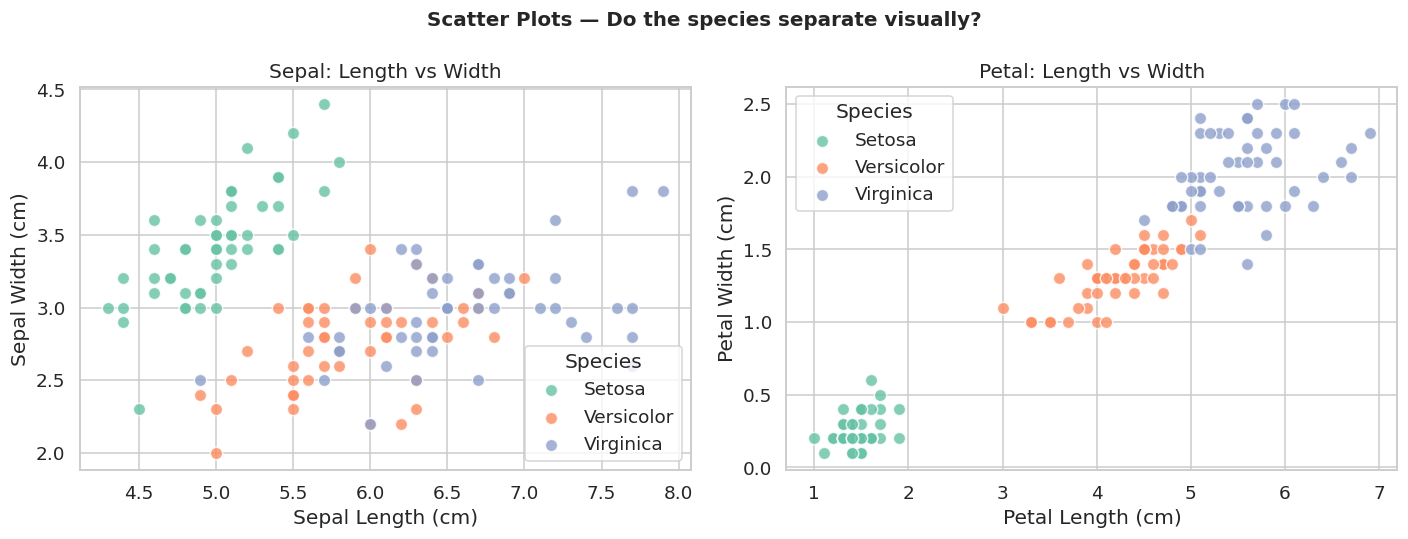

In [7]:
colors = {'setosa': '#66c2a5', 'versicolor': '#fc8d62', 'virginica': '#8da0cb'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Scatter Plots — Do the species separate visually?', fontsize=13, fontweight='bold')

# left plot: sepal dimensions
for sp, group in df.groupby('species'):
    axes[0].scatter(group['sepal_length'], group['sepal_width'],
                    label=sp.capitalize(), color=colors[sp],
                    alpha=0.8, edgecolors='white', s=65)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Sepal: Length vs Width')
axes[0].legend(title='Species')

# right plot: petal dimensions — usually more separable
for sp, group in df.groupby('species'):
    axes[1].scatter(group['petal_length'], group['petal_width'],
                    label=sp.capitalize(), color=colors[sp],
                    alpha=0.8, edgecolors='white', s=65)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Petal: Length vs Width')
axes[1].legend(title='Species')

plt.tight_layout()
plt.savefig('scatter_plots.png', bbox_inches='tight')
plt.show()

The petal plot (right) is way more interesting — the three species are clearly in different zones. Setosa especially sits completely apart from the other two. The sepal plot is more mixed.

This already tells me: if I were to build a classifier later, petal measurements would probably be way more useful than sepal measurements.

### Pair plot — all combinations at once

Instead of making separate scatter plots for every pair of features, seaborn has a `pairplot()` function that does all of them in one grid. The diagonal shows the distribution of each feature.

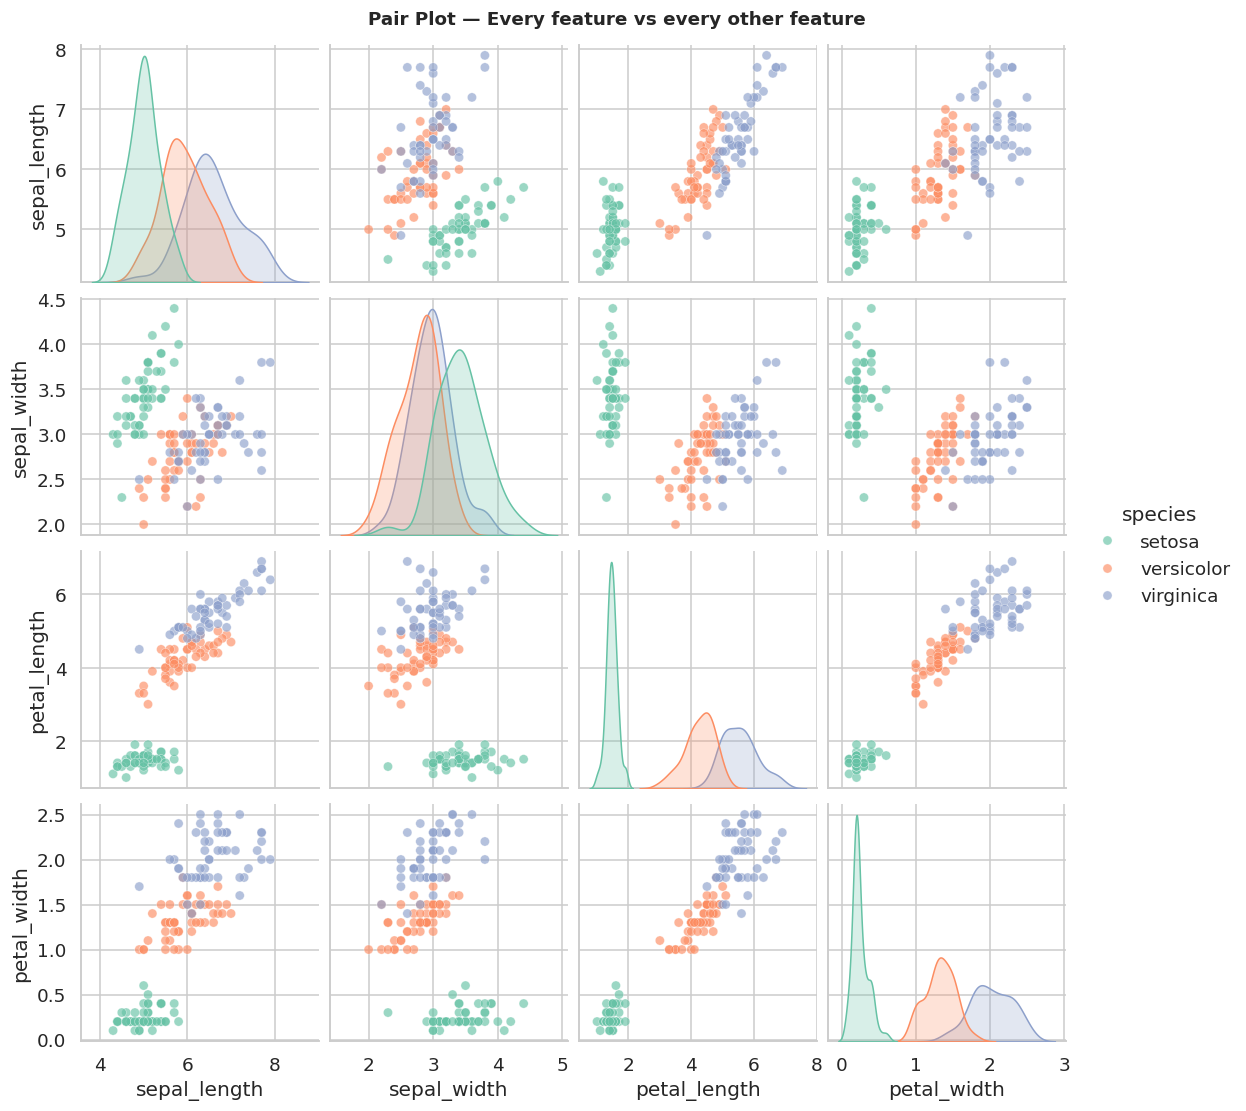

In [8]:
g = sns.pairplot(
    df,
    hue='species',
    palette=colors,
    diag_kind='kde',
    plot_kws={'alpha': 0.65, 'edgecolor': 'white', 'linewidth': 0.3}
)
g.figure.suptitle('Pair Plot — Every feature vs every other feature', y=1.01, fontsize=12, fontweight='bold')
g.savefig('pair_plot.png', bbox_inches='tight')
plt.show()

Anywhere you see petal_length or petal_width on an axis, the species separate cleanly. The sepal_width combinations are messier — lots of overlap there.

### Histograms — how are values distributed?

For each feature, I want to see the shape of the distribution per species. Are they spread out? Overlapping? Skewed? Histograms answer that.

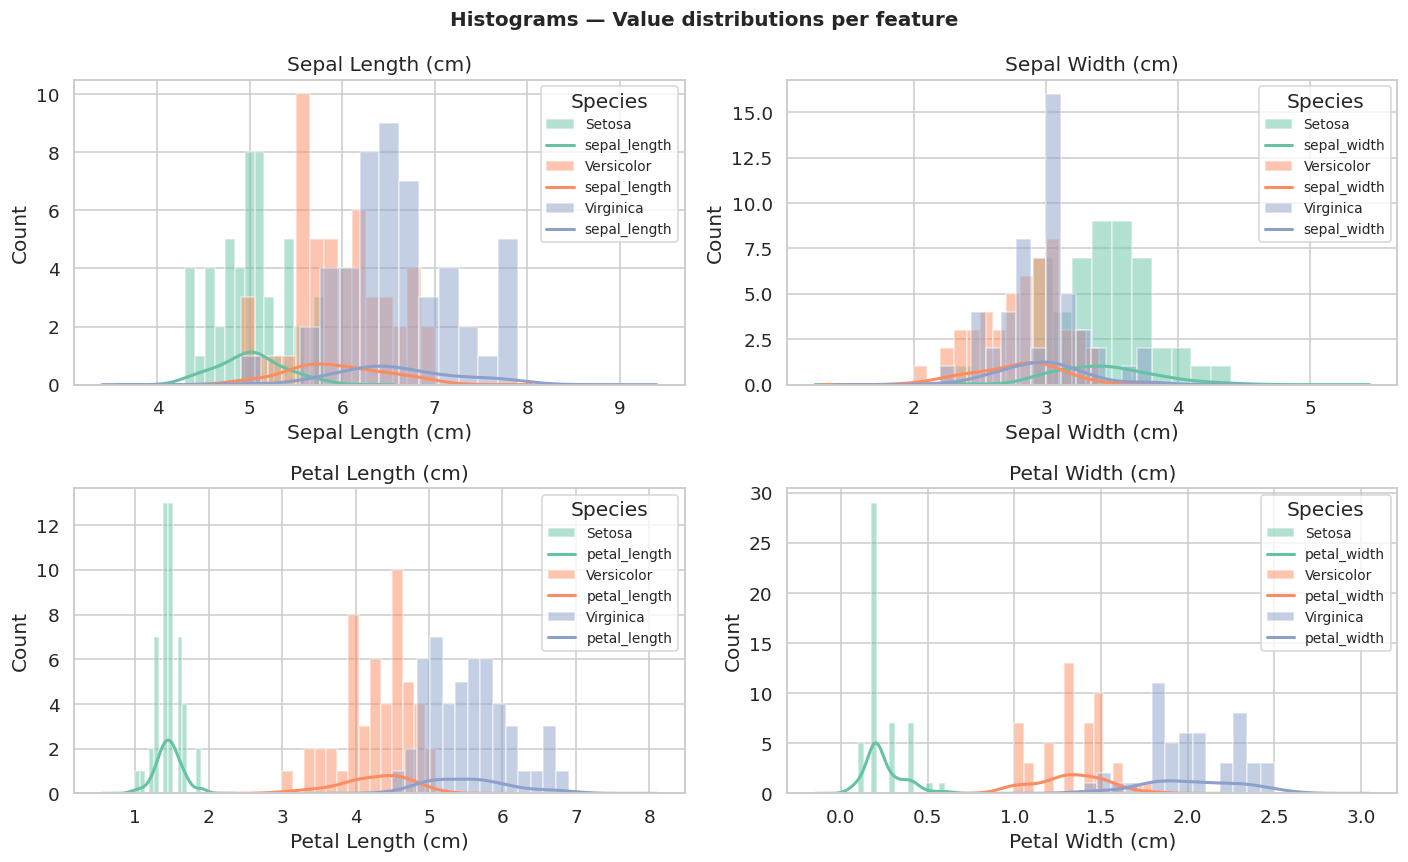

In [9]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
labels   = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Histograms — Value distributions per feature', fontsize=13, fontweight='bold')

for ax, feat, lab in zip(axes.flatten(), features, labels):
    for sp in df['species'].unique():
        data = df[df['species'] == sp][feat]
        ax.hist(data, bins=14, alpha=0.5, label=sp.capitalize(), color=colors[sp], edgecolor='white')
        data.plot.kde(ax=ax, color=colors[sp], linewidth=2)  # smooth curve on top

    ax.set_xlabel(lab)
    ax.set_ylabel('Count')
    ax.set_title(lab)
    ax.legend(title='Species', fontsize=9)

plt.tight_layout()
plt.savefig('histograms.png', bbox_inches='tight')
plt.show()

For petal length and petal width, you can see the three species have almost no overlap in their distributions. For sepal width, everything is mixed together. Same story as before — petals are the better features.

### Box plots — spotting outliers

Box plots are great for seeing the spread of data and finding outliers. The box shows where 50% of the data sits (the middle range), the line in the middle is the median, and the dots outside the whiskers are potential outliers.

/tmp/ipykernel_30/1385949358.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_30/1385949358.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
/tmp/ipykernel_30/1385949358.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_30/1385949358.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
/tmp/ipykernel_30/1385949358.py:5: FutureWarning: 

Passing `palette` without assignin

/tmp/ipykernel_30/1385949358.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
/tmp/ipykernel_30/1385949358.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_30/1385949358.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])


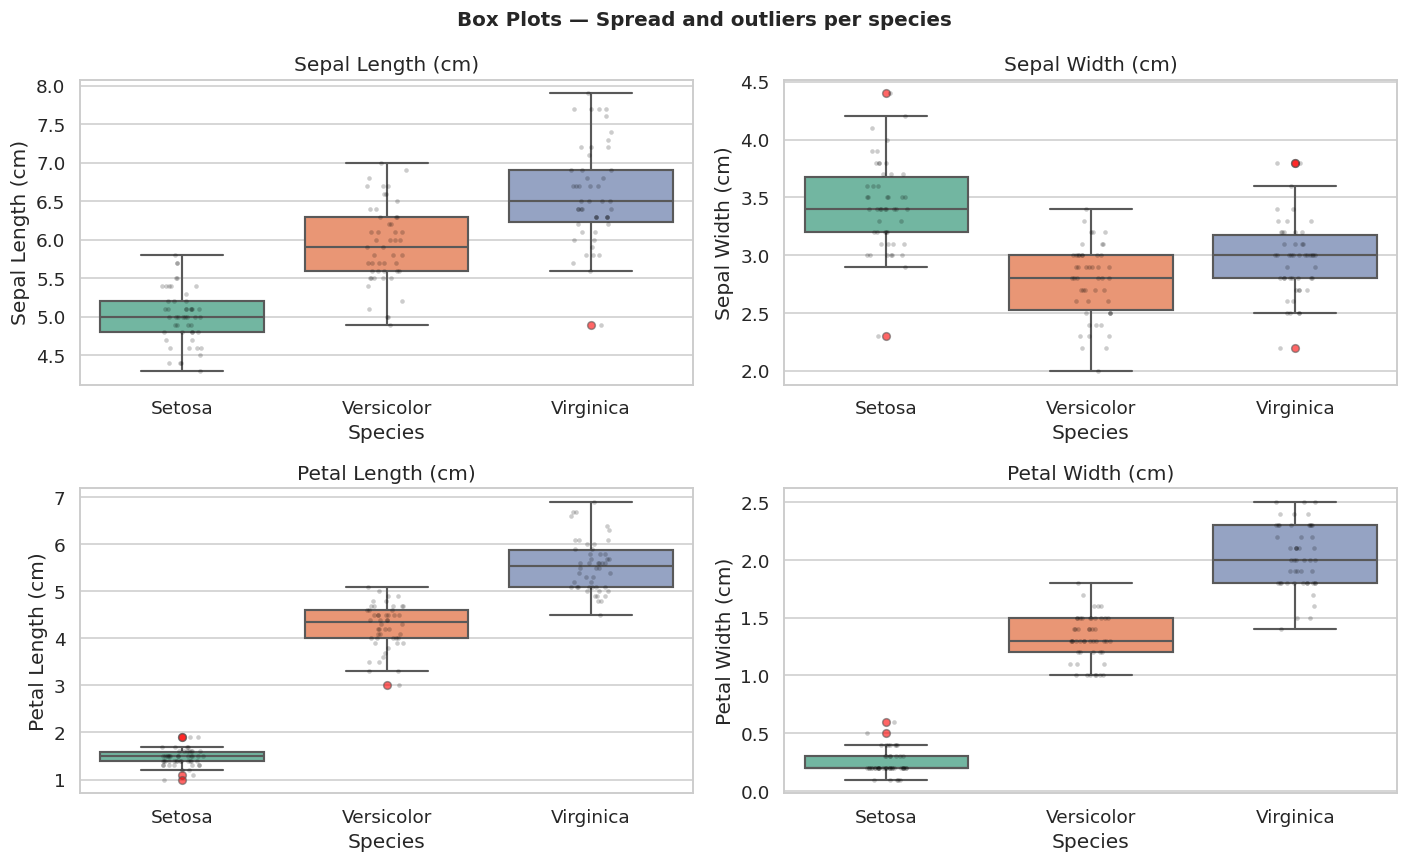

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Box Plots — Spread and outliers per species', fontsize=13, fontweight='bold')

for ax, feat, lab in zip(axes.flatten(), features, labels):
    sns.boxplot(
        data=df, x='species', y=feat,
        palette=colors, linewidth=1.4,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6),
        ax=ax
    )
    # adding the actual data points on top so we can see individual samples
    sns.stripplot(data=df, x='species', y=feat,
                  color='black', alpha=0.2, size=3, jitter=True, ax=ax)

    ax.set_title(lab)
    ax.set_xlabel('Species')
    ax.set_ylabel(lab)
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

There are a few outlier points (shown in red) here and there, but nothing extreme. The dataset is quite clean overall. Also notice how the boxes for petal features don't really overlap between species — more confirmation that those are the better features to use.

### Correlation heatmap

This shows how strongly each pair of features is related to each other. A value close to 1 means they move together (if one goes up, so does the other). Close to -1 means the opposite. Close to 0 means no real relationship.

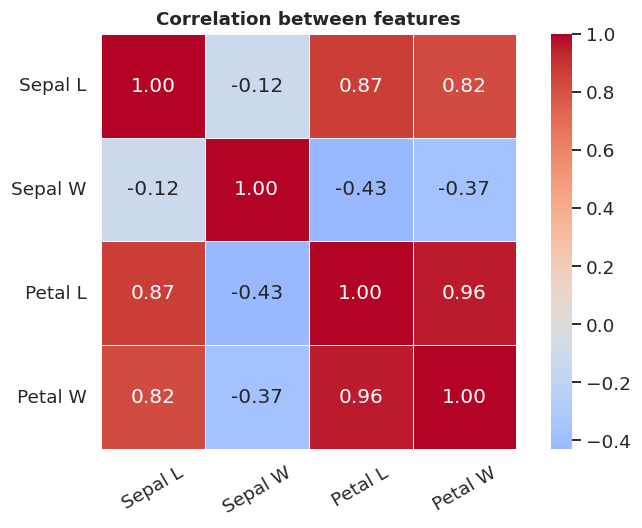

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

corr = df[features].corr().round(2)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, ax=ax)

ax.set_title('Correlation between features', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Sepal L', 'Sepal W', 'Petal L', 'Petal W'], rotation=30)
ax.set_yticklabels(['Sepal L', 'Sepal W', 'Petal L', 'Petal W'], rotation=0)

plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

Petal length and petal width have a correlation of 0.96 — they're almost measuring the same thing. That's useful to know because if I later build a model, I might not need both.

---

## Summary

Here's what I found from this exploration:

In [12]:
# average values per species — nice to look at
df.groupby('species')[features].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


**What I learned from this task:**

- Petal length and petal width are the most useful features — they cleanly separate all three species visually
- Setosa is the easiest to identify — it has noticeably smaller petals compared to the other two
- Versicolor and Virginica are harder to tell apart, especially using sepal measurements
- Sepal width is the weakest feature — lots of overlap between all three species
- The dataset is clean (no missing values), balanced (50 per class), and ready to use for modeling
- Petal length and petal width are highly correlated (0.96), so they carry similar information

Overall this is a well-structured dataset and the EDA (exploratory data analysis) already gives a strong hint that a simple classifier should do well on this data.